# LSTM- CODE

### LSTM-based Paragraph Summarizer

This section demonstrates how to build a basic sequence-to-sequence (Seq2Seq) model with Long Short-Term Memory (LSTM) layers and an attention mechanism for text summarization. The model will take a longer text as input and generate a shorter, coherent summary.

In [ ]:
# Install necessary libraries
!pip install -q tensorflow nltk

# Import libraries
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Embedding, Attention
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np
import re
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')


### 1. Text Preprocessing

We need to clean and prepare our text data before feeding it into the LSTM model. This involves lowercasing, removing special characters, and tokenization.

In [ ]:
STOP_WORDS = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z0-9\s]', '', text) # Remove special characters
    text = ' '.join([word for word in text.split() if word not in STOP_WORDS]) # Remove stopwords
    return text

def tokenize_and_pad(texts, max_len, tokenizer=None, fit_tokenizer=False):
    if fit_tokenizer:
        tokenizer = Tokenizer(oov_token='<unk>')
        tokenizer.fit_on_texts(texts)

    sequences = tokenizer.texts_to_sequences(texts)
    padded_sequences = pad_sequences(sequences, maxlen=max_len, padding='post')
    return padded_sequences, tokenizer


### 2. Prepare Sample Data

For a real summarization task, you would use a large dataset of `(document, summary)` pairs. Here, we'll use a small example to demonstrate the workflow. We will also define vocabulary sizes and maximum sequence lengths.

In [ ]:
long_text = [
    "The quick brown fox jumps over the lazy dog. This is a classic sentence used for testing typewriters and computer keyboards. It contains all the letters of the alphabet, making it a pangram. The fox was very agile and managed to clear the sleeping canine with ease. The dog, being lazy, did not even stir from its nap, continuing to dream of bones and treats."
]

# A very short, illustrative summary for the example. In reality, summaries are generated.
short_summary = [
    "quick brown fox jumps over lazy dog, classic pangram."
]

# Clean the texts
cleaned_long_text = [clean_text(text) for text in long_text]
cleaned_short_summary = [clean_text(text) for text in short_summary]

# Add start and end tokens for decoder input/output
decoder_input = [f'<start> {summary}' for summary in cleaned_short_summary]
decoder_output = [f'{summary} <end>' for summary in cleaned_short_summary]

print("Cleaned Long Text:", cleaned_long_text[0])
print("Decoder Input:", decoder_input[0])
print("Decoder Output:", decoder_output[0])

# Parameters
MAX_INPUT_LENGTH = 50
MAX_OUTPUT_LENGTH = 15
EMBEDDING_DIM = 100
LATENT_DIM = 256 # Dimensionality of the output space

# Tokenize and pad input text
input_sequences, input_tokenizer = tokenize_and_pad(cleaned_long_text, MAX_INPUT_LENGTH, fit_tokenizer=True)
input_vocab_size = len(input_tokenizer.word_index) + 1

# Tokenize and pad decoder input/output
decoder_input_sequences, output_tokenizer = tokenize_and_pad(decoder_input, MAX_OUTPUT_LENGTH, fit_tokenizer=True)
decoder_output_sequences, _ = tokenize_and_pad(decoder_output, MAX_OUTPUT_LENGTH, output_tokenizer) # Use same tokenizer
output_vocab_size = len(output_tokenizer.word_index) + 1

print("\nSample Input Sequence:", input_sequences[0])
print("Sample Decoder Input Sequence:", decoder_input_sequences[0])
print("Sample Decoder Output Sequence:", decoder_output_sequences[0])


### 3. Build the Encoder-Decoder LSTM Model with Attention

We'll construct a Seq2Seq model. The encoder processes the input text and generates a context vector (hidden states and cell states). The decoder then uses this context vector, along with an attention mechanism, to generate the summary word by word.

In [ ]:
# Encoder
encoder_inputs = Input(shape=(MAX_INPUT_LENGTH,))
encoder_embedding = Embedding(input_vocab_size, EMBEDDING_DIM, mask_zero=True)(encoder_inputs)
encoder_lstm = LSTM(LATENT_DIM, return_sequences=True, return_state=True)
encoder_outputs, state_h, state_c = encoder_lstm(encoder_embedding)
encoder_states = [state_h, state_c]

# Decoder
decoder_inputs = Input(shape=(MAX_OUTPUT_LENGTH,))
decoder_embedding = Embedding(output_vocab_size, EMBEDDING_DIM, mask_zero=True)(decoder_inputs)
decoder_lstm = LSTM(LATENT_DIM, return_sequences=True, return_state=True)
decoder_outputs, _, _ = decoder_lstm(decoder_embedding, initial_state=encoder_states)

# Attention Layer
attention_layer = Attention()
attention_output = attention_layer([decoder_outputs, encoder_outputs])

# Concatenate attention output and decoder LSTM output
decoder_concat_input = tf.keras.layers.Concatenate(axis=-1)([decoder_outputs, attention_output])

# Dense layer to output probabilities for each word in the vocabulary
decoder_dense = Dense(output_vocab_size, activation='softmax')
decoder_outputs = decoder_dense(decoder_concat_input)

# Define the full model
model = Model([encoder_inputs, decoder_inputs], decoder_outputs)

# Compile the model
model.compile(optimizer='rmsprop', loss='sparse_categorical_crossentropy')

print("Model Summary:")
model.summary()


### 4. Training the Model (Conceptual)

For actual training, you would need a large dataset of `(document, summary)` pairs. The model would be trained to predict the next word in the summary given the previous words and the encoded input text. The `decoder_output_sequences` should be one-hot encoded for `sparse_categorical_crossentropy` if not using `from_logits=True`.

Since training a meaningful summarization model requires significant data and computational resources, we will skip actual training here and focus on the inference part with a simplified example. You would typically train it like this:

```python
# Dummy target data for demonstration (one-hot encoded output)
target_data = np.expand_dims(decoder_output_sequences, -1)

# model.fit(
#     [input_sequences, decoder_input_sequences],
#     target_data,
#     batch_size=64,
#     epochs=50, # Many more epochs needed for real training
#     validation_split=0.2
# )
```

### 5. Inference (Summarization)

To generate a summary, we need two separate models: an encoder model and a decoder model. The encoder will process the input text and output its internal states. The decoder will then take these states and iteratively predict the summary words.

In [ ]:
# Encoder inference model
encoder_model = Model(encoder_inputs, encoder_states)

# Decoder inference model setup
decoder_state_h_input = Input(shape=(LATENT_DIM,))
decoder_state_c_input = Input(shape=(LATENT_DIM,))
decoder_states_inputs = [decoder_state_h_input, decoder_state_c_input]

decoder_outputs, state_h, state_c = decoder_lstm(decoder_embedding, initial_state=decoder_states_inputs)
decoder_states = [state_h, state_c]

# Attention for inference
encoder_outputs_inference = Input(shape=(MAX_INPUT_LENGTH, LATENT_DIM))
attention_output_inference = attention_layer([decoder_outputs, encoder_outputs_inference])
decoder_concat_input_inference = tf.keras.layers.Concatenate(axis=-1)([decoder_outputs, attention_output_inference])

decoder_outputs_inference = decoder_dense(decoder_concat_input_inference)

decoder_model = Model(
    [decoder_inputs] + decoder_states_inputs + [encoder_outputs_inference],
    [decoder_outputs_inference] + decoder_states
)

# Reverse lookup dictionaries for decoding sequences back to words
reverse_input_word_index = dict((i, word) for word, i in input_tokenizer.word_index.items())
reverse_target_word_index = dict((i, word) for word, i in output_tokenizer.word_index.items())

def decode_sequence(input_seq):
    # Get initial states from the encoder
    encoder_output_states, h, c = encoder_lstm(encoder_embedding(tf.constant(input_seq)))

    # Generate empty target sequence of length 1
    target_seq = np.zeros((1, 1))
    # Populate the first word of target sequence with the start token's index
    target_seq[0, 0] = output_tokenizer.word_index['<start>']

    stop_condition = False
    decoded_sentence = ''
    while not stop_condition:
        output_tokens, h, c = decoder_model.predict([target_seq] + [h, c] + [encoder_output_states])

        # Sample a token
        sampled_token_index = np.argmax(output_tokens[0, -1, :])
        sampled_word = reverse_target_word_index.get(sampled_token_index, '')

        if (sampled_word == '<end>' or len(decoded_sentence.split()) >= MAX_OUTPUT_LENGTH - 1):
            stop_condition = True
        else:
            decoded_sentence += ' ' + sampled_word

        # Update the target sequence (of length 1).
        target_seq = np.zeros((1, 1))
        target_seq[0, 0] = sampled_token_index

    return decoded_sentence.strip()


### 6. Test with Example Text

Since the model was not trained on a real dataset, the output here will be random words from the vocabulary due to untrained weights. For a functional summarizer, you would need to train the `model` defined above on a large dataset of `(document, summary)` pairs.

In [ ]:
test_text = long_text[0]

# Preprocess the test text
cleaned_test_text = clean_text(test_text)
input_seq, _ = tokenize_and_pad([cleaned_test_text], MAX_INPUT_LENGTH, input_tokenizer)

print("Original Text:", test_text)
print("\nGenerated Summary (Note: Model is untrained, so output will be random words):")

# This will produce random words as the model is not trained.
# To get meaningful summaries, you'd need to train the model extensively.
print(decode_sequence(input_seq))


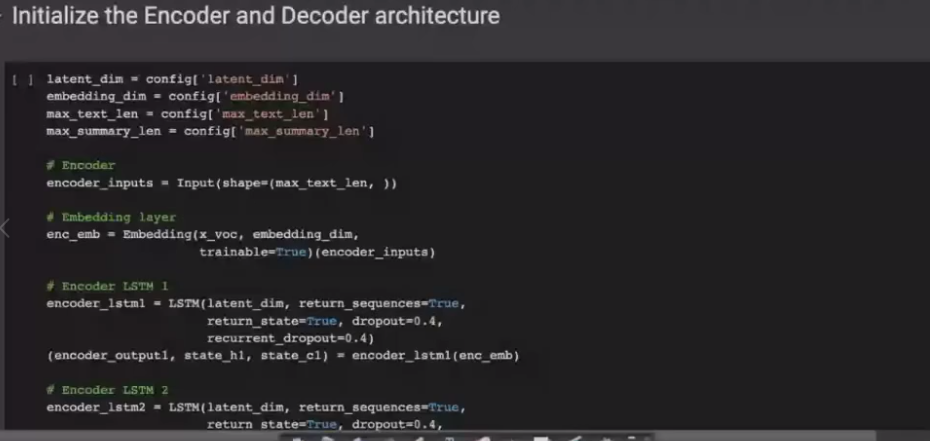

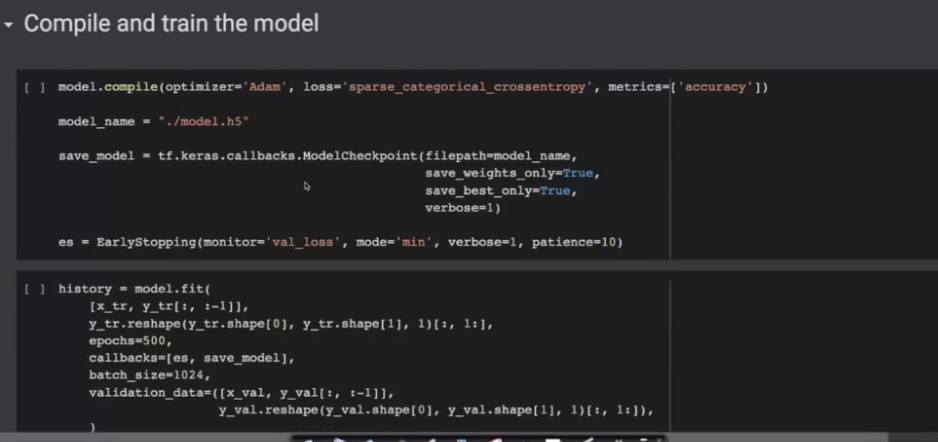

# NER

# Named Entity Recognition (NER) in NLP

Named Entity Recognition (NER) is a subtask of information extraction that seeks to locate and classify named entities in unstructured text into pre-defined categories such as person names, organizations, locations, medical codes, time expressions, quantities, monetary values, percentages, etc.

NER is a crucial component in many NLP applications, including:
-   **Information Extraction:** Automatically extracting structured information from unstructured text.
-   **Question Answering:** Identifying key entities in questions and passages to find relevant answers.
-   **Text Summarization:** Highlighting important entities to create concise summaries.
-   **Machine Translation:** Ensuring proper translation of named entities.
-   **Content Recommendation:** Understanding entities in user preferences to suggest relevant content.

We will explore NER using two popular Python libraries: NLTK and spaCy.

## 1. NER with NLTK

NLTK (Natural Language Toolkit) provides basic functionality for NER, often relying on Part-of-Speech (POS) tagging and chunking. It's suitable for introductory examples but less robust than dedicated NER libraries for complex tasks.

In [ ]:
# Import NLTK components
import nltk
from nltk.tokenize import word_tokenize
from nltk.tag import pos_tag
from nltk.chunk import ne_chunk

# Download necessary NLTK data (if not already downloaded)
try:
    nltk.data.find('tokenizers/punkt')
except nltk.downloader.DownloadError:
    nltk.download('punkt')
try:
    nltk.data.find('taggers/averaged_perceptron_tagger')
except nltk.downloader.DownloadError:
    nltk.download('averaged_perceptron_tagger')
try:
    nltk.data.find('chunkers/maxent_ne_chunker')
except nltk.downloader.DownloadError:
    nltk.download('maxent_ne_chunker')
try:
    nltk.data.find('corpora/words')
except nltk.downloader.DownloadError:
    nltk.download('words')

# Sample text
text = "Apple Inc. was founded by Steve Jobs, Steve Wozniak, and Ronald Wayne on April 1, 1976, in California. Its headquarters are in Cupertino."

print("Original Text:", text)

# Step 1: Tokenize the text
words = word_tokenize(text)
print("\nTokens:", words)

# Step 2: Part-of-Speech Tagging
pos_tags = pos_tag(words)
print("\nPOS Tags:", pos_tags)

# Step 3: Named Entity Chunking
# NLTK uses a chunk parser to identify named entities based on POS tags
ne_tree = ne_chunk(pos_tags)

print("\nNamed Entities (NLTK Tree Format):\n")
# Print the tree structure for better readability
for subtree in ne_tree.subtrees():
    if subtree.label():
        print(f"  {subtree.label()}: {' '.join([word for word, tag in subtree.leaves()])}")

# You can also iterate through the leaves to get entities directly
print("\nExtracted Entities (flat list):")
entities = []
for chunk in ne_tree:
    if hasattr(chunk, 'label') and chunk.label():
        entities.append((chunk.label(), ' '.join(c[0] for c in chunk)))
print(entities)


## 2. NER with spaCy

spaCy is a more advanced and production-ready library for NLP in Python. It offers highly optimized and pre-trained models for various languages, including excellent NER capabilities. spaCy models are generally faster and more accurate than NLTK's rule-based chunking for NER.

In [ ]:
# Install spaCy
!pip install -q spacy

# Download a pre-trained spaCy model
# 'en_core_web_sm' is a small English model
!python -m spacy download en_core_web_sm

import spacy

# Load the English model
try:
    nlp = spacy.load("en_core_web_sm")
except OSError:
    print("Downloading en_core_web_sm model...")
    !python -m spacy download en_core_web_sm
    nlp = spacy.load("en_core_web_sm")

# Sample text
text = "Apple Inc. was founded by Steve Jobs, Steve Wozniak, and Ronald Wayne on April 1, 1976, in California. Its headquarters are in Cupertino. The company generated 394.3 billion USD in revenue in 2022."

# Process the text with the spaCy model
doc = nlp(text)

print("Original Text:", text)
print("\nNamed Entities (spaCy):")
for ent in doc.ents:
    print(f"  {ent.text} ({ent.label_})")

print("\nExplanation of Entity Types:")
for ent in doc.ents:
    print(f"  {ent.label_}: {spacy.explain(ent.label_)}")


### Visualizing NER with spaCy's `displacy`

spaCy provides a built-in visualizer called `displacy` that can render named entities directly in your notebook, making it easy to inspect the results.

In [ ]:
from spacy import displacy

# Render entities in the notebook
displacy.render(doc, style="ent", jupyter=True)


## Conclusion

NER is a fundamental task in NLP. While NLTK offers basic capabilities, spaCy provides a more sophisticated and production-ready solution with pre-trained models and excellent visualization tools for identifying and classifying named entities in text. For most real-world applications, spaCy is the preferred choice for NER.

# ROUGE in NLP

ROUGE (Recall-Oriented Understudy for Gisting Evaluation) is a set of metrics used for evaluating automatic summarization and machine translation software in natural language processing. It works by comparing an automatically produced summary or translation against a set of reference (human-produced) summaries or translations.

The core idea behind ROUGE is to count the number of overlapping units (such as n-grams, word sequences, or word pairs) between the candidate (system-generated) text and the reference text. Higher overlap indicates higher quality.

### Common ROUGE Metrics:

1.  **ROUGE-N (N-gram Overlap)**:
    *   **ROUGE-1**: Measures the overlap of unigrams (single words) between the candidate and reference summaries. It's useful for assessing the presence of key information.
    *   **ROUGE-2**: Measures the overlap of bigrams (pairs of words). This captures more of the fluency and grammaticality of the summary.
    *   **ROUGE-N**: Generalizes to n-grams of any length. It's calculated as:
        ```
        ROUGE-N = (Number of overlapping N-grams) / (Total number of N-grams in reference summary)
        ```

2.  **ROUGE-L (Longest Common Subsequence)**:
    *   Measures the longest common subsequence (LCS) between the candidate and reference summaries. LCS does not require consecutive matches but reflects sentence-level structure similarity. It's often preferred for capturing the main ideas and overall flow.
    *   It calculates Precision, Recall, and an F-measure based on the LCS length.

3.  **ROUGE-S (Skip-Bigram Co-occurrence Statistics)**:
    *   Counts pairs of words that appear in both the candidate and reference summaries, allowing for arbitrary gaps (skips) between the words. This helps to capture sentence-level semantic similarity even if the word order is not strictly preserved.

### Why ROUGE is important:

*   **Objective Evaluation**: Provides a quantitative measure to compare different summarization or translation systems.
*   **Handles Variability**: By comparing against multiple reference summaries, it can account for the fact that there are many ways to summarize or translate a text correctly.
*   **Standard Metric**: Widely adopted in academic research and industry for benchmarking NLP models.

Let's see an example of how to calculate ROUGE scores in Python.

In [ ]:
# Install the rouge-score library
!pip install -q rouge-score

from rouge_score import rouge_scorer

# Sample candidate and reference summaries
candidate_summary = "The cat sat on the mat. It was a lazy cat."
reference_summary_1 = "The cat was on the mat. The cat was lazy."
reference_summary_2 = "A cat sat on a mat, being lazy."

# Create a scorer object
# You can specify which ROUGE types you want to calculate
scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL', 'rougeLsum'], use_stemmer=True)

# Calculate scores for a single reference
print("\n--- Scores against Reference 1 ---")
scores_ref1 = scorer.score(reference_summary_1, candidate_summary)
for key, value in scores_ref1.items():
    print(f"{key}: Recall={value.recall:.4f}, Precision={value.precision:.4f}, F-measure={value.fmeasure:.4f}")

# To get a more robust evaluation, especially with multiple human-written references,
# you would typically average the scores across references or pick the highest.
# Here, we'll just demonstrate individual scores.
print("\n--- Scores against Reference 2 ---")
scores_ref2 = scorer.score(reference_summary_2, candidate_summary)
for key, value in scores_ref2.items():
    print(f"{key}: Recall={value.recall:.4f}, Precision={value.precision:.4f}, F-measure={value.fmeasure:.4f}")

# For a more advanced use case, you might have multiple candidates and multiple references.
# The 'rouge_scorer' also supports lists of references.
# Example for multiple references (internally, it will take the best match for each metric)
print("\n--- Scores against Multiple References (taking max for each metric) ---")
multiple_references = [reference_summary_1, reference_summary_2]

# Note: The `rouge_score` library's `score` method expects the *first* argument to be the reference and the *second* to be the candidate.
# If you provide a list as the first argument, it assumes it's a list of references and computes the max ROUGE score for each metric.
scores_multi_ref = scorer.score_multi(multiple_references, candidate_summary)

for key, value in scores_multi_ref.items():
    # For multi-reference, the output structure is slightly different
    # It returns a dictionary of values for each metric
    print(f"{key}: Recall={value.recall:.4f}, Precision={value.precision:.4f}, F-measure={value.fmeasure:.4f}")



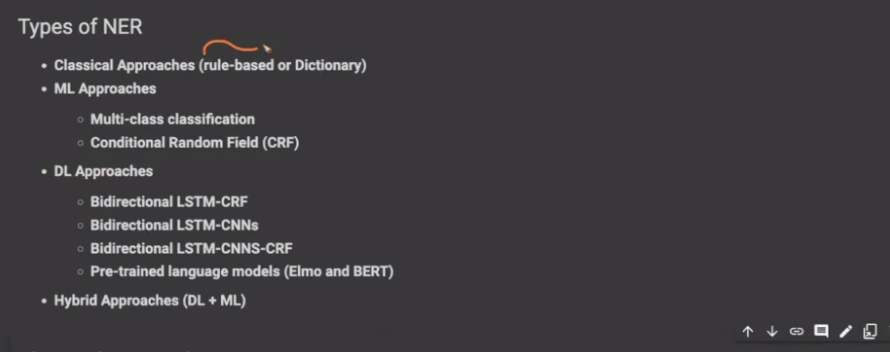

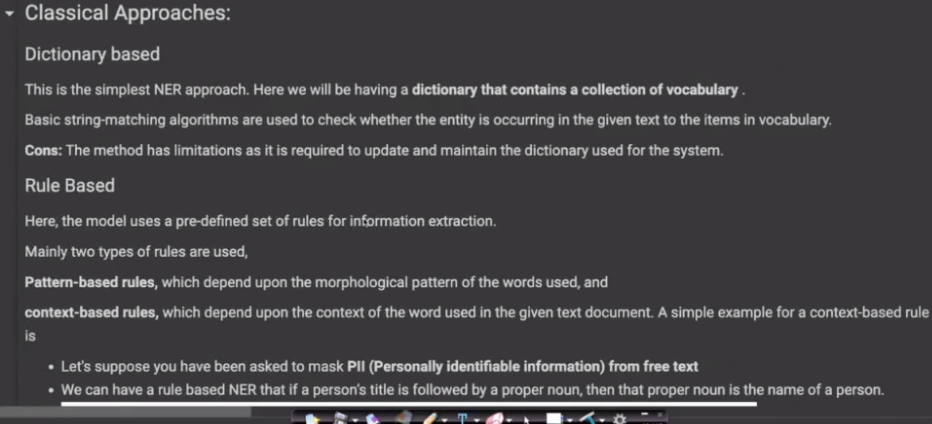

   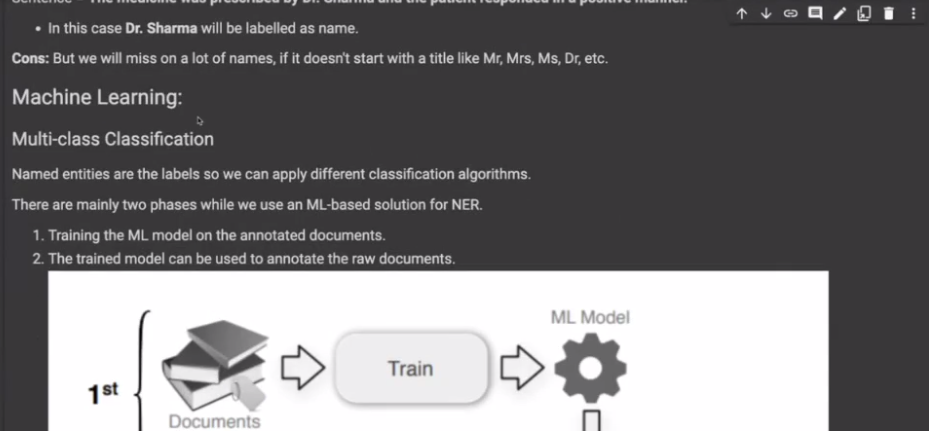

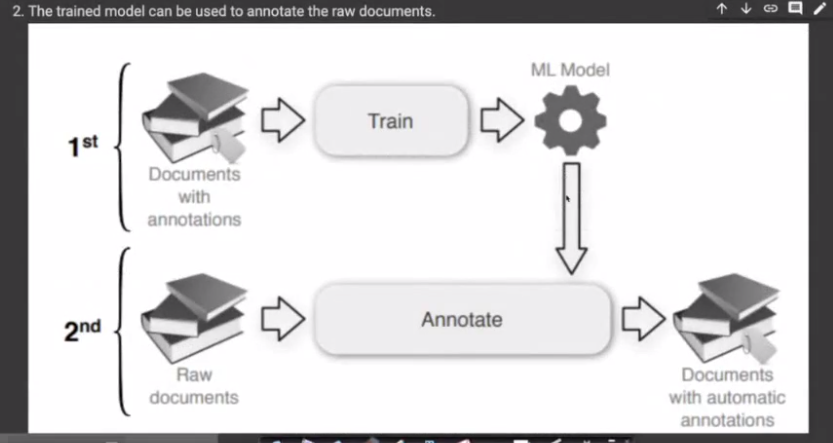

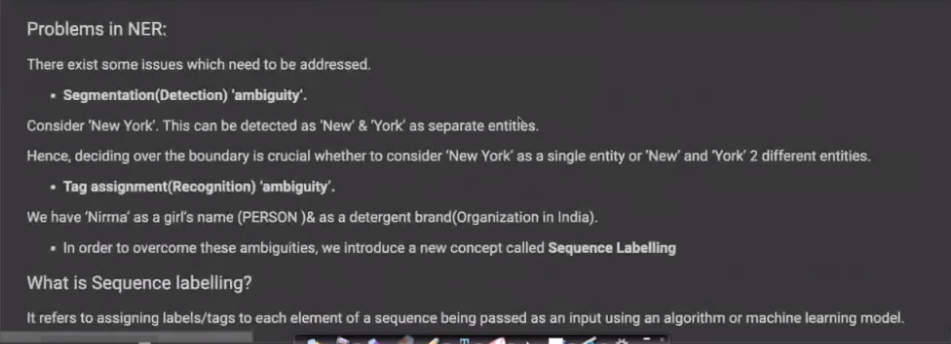

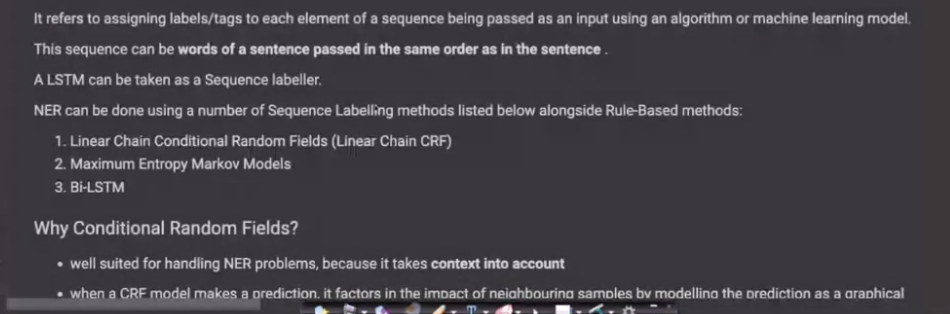

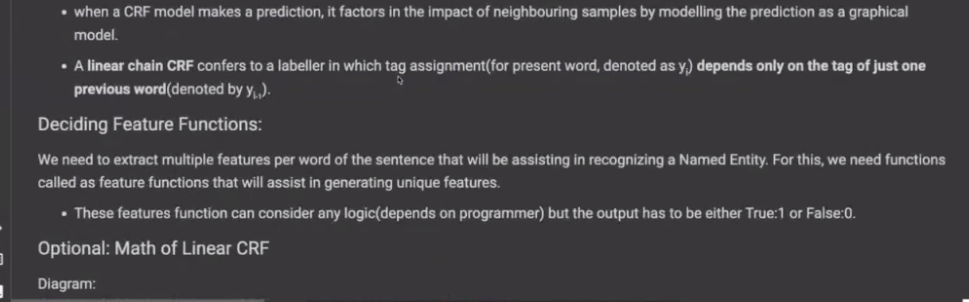

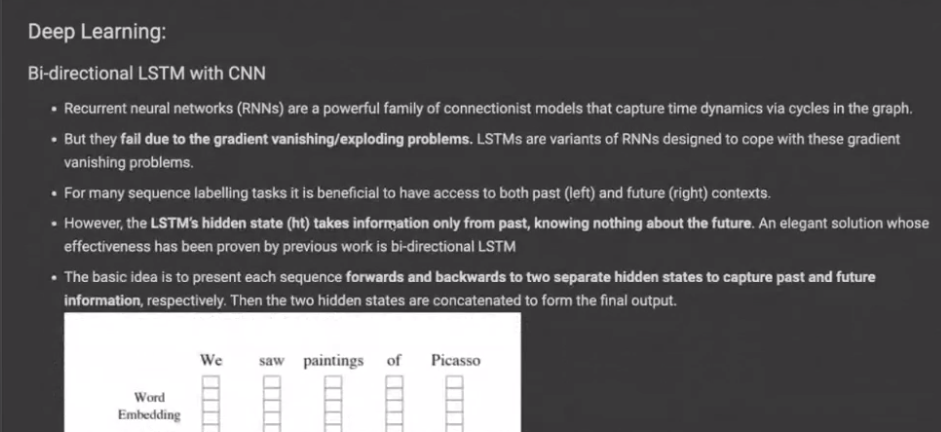

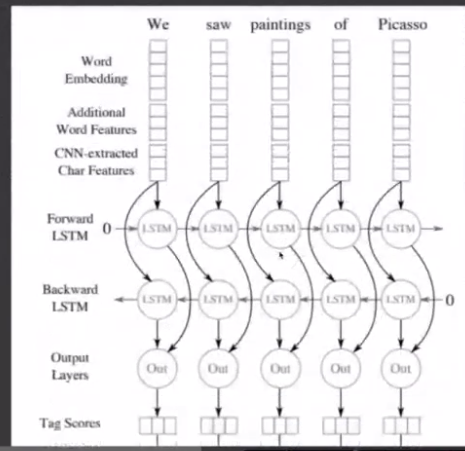

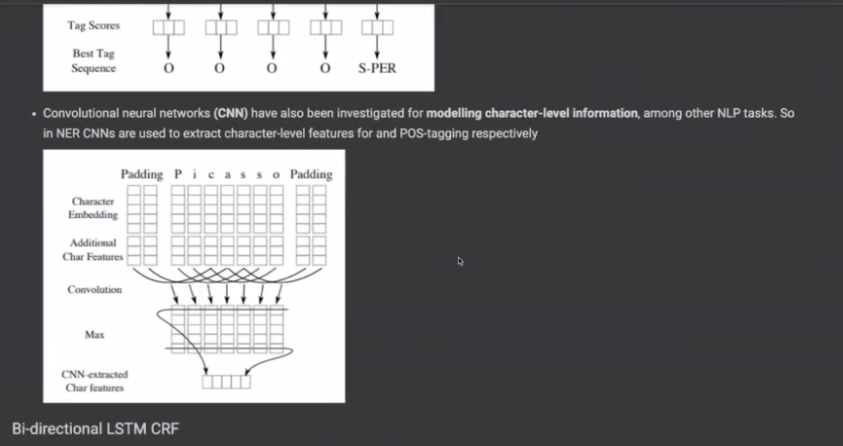

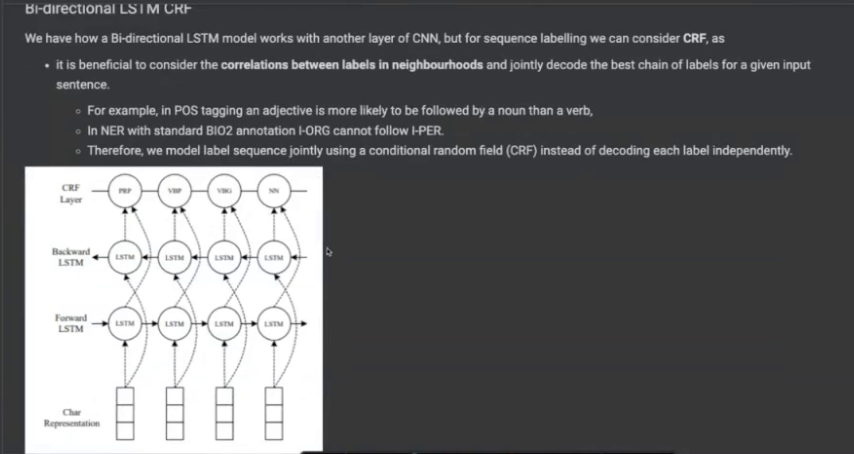